In [1]:
!pip install graphviz

     |████████████████████████████████| 47 kB 2.6 MB/s eta 0:00:011


In [2]:
from graphviz import Digraph

# Create a new directed graph
dot = Digraph(comment='Clinical Reasoning Tree')

# Root node
dot.node('A', 'Patient with AIDS and\npainful umbilicated papulopustules\n+ ulcerated plaques + new cough\n(afebrile, no systemic symptoms)')

# Tzanck smear diagnostic test
dot.node('B', 'Tzanck smear:\nBallooning keratinocytes\n+ nuclear peripheralization\n→ Herpesvirus infection')

dot.edge('A', 'B', label='Perform Tzanck smear')

# Diagnostic options
dot.node('C1', 'Herpes simplex virus\n✔ Painful ulcers\n✔ Matches Tzanck smear\n✔ Common in AIDS')
dot.node('C2', 'Histoplasmosis\n✘ No fever/systemic features\n✘ Lesion mismatch\n✘ Tzanck mismatch')
dot.node('C3', 'Molluscum contagiosum\n✘ Typically painless\n✘ No Tzanck findings')
dot.node('C4', 'Mpox (Monkeypox)\n✘ Afebrile\n✘ No prodrome\n✘ Tzanck mismatch')

dot.edge('B', 'C1', label='Most consistent')
dot.edge('B', 'C2', label='Less likely')
dot.edge('B', 'C3', label='Less likely')
dot.edge('B', 'C4', label='Less likely')

# Final decision
dot.node('D', 'Final Diagnosis:\nHerpes simplex virus', shape='box', style='filled', color='lightblue')

dot.edge('C1', 'D', label='Confirmed by cytology + clinical picture')

# Render diagram
dot.render('clinical_reasoning_tree', format='png', cleanup=True)
print("Decision tree saved as 'clinical_reasoning_tree.png'")


Decision tree saved as 'clinical_reasoning_tree.png'


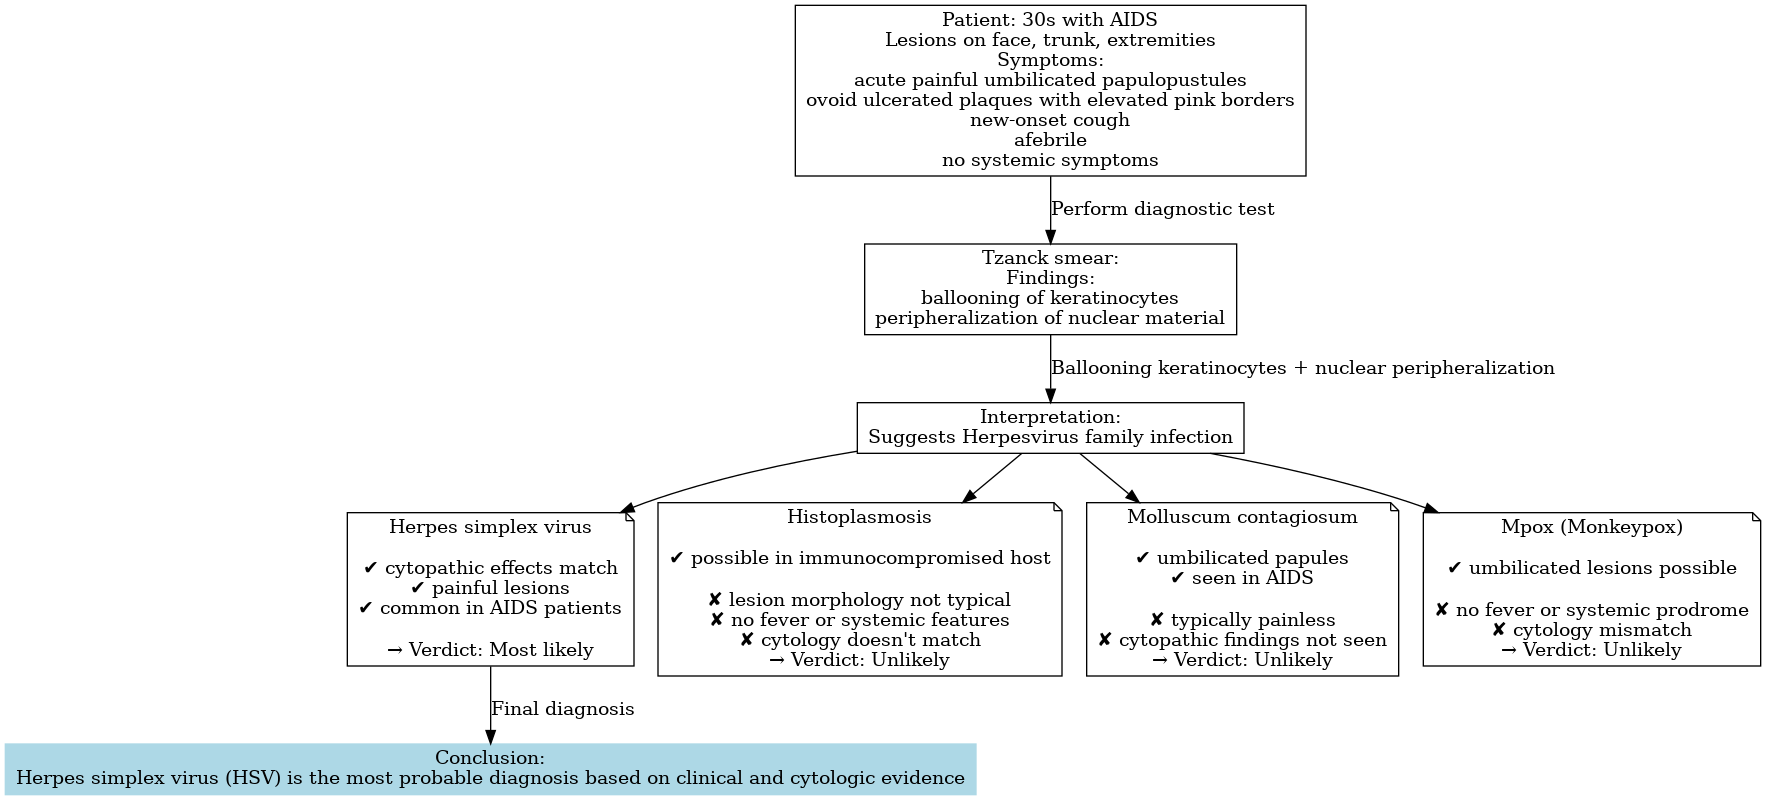

In [4]:
import json
from graphviz import Digraph

# Load JSON file
with open('Sample1.json', 'r') as f:
    data = json.load(f)

# Create a new directed graph
dot = Digraph(comment='Clinical Reasoning Tree')
dot.attr(rankdir='TB', fontsize='10')

# Step 1: Basic clinical presentation
case = data['patient_case']
symptoms = '\n'.join(case['symptoms'])
locations = ', '.join(case['lesion_locations'])

dot.node('A', f"Patient: {case['age']} with {case['condition']}\nLesions on {locations}\nSymptoms:\n{symptoms}", shape='box')

# Step 2: Tzanck smear test
test = data['diagnostic_test']
findings = '\n'.join(test['findings'])

dot.node('B', f"{test['name']}:\nFindings:\n{findings}", shape='box')
dot.edge('A', 'B', label='Perform diagnostic test')

# Step 3: Interpretation node
tree = data['reasoning_tree']
branch = tree['branch'][0]

dot.node('C', f"Interpretation:\n{branch['interpretation']}", shape='box')
dot.edge('B', 'C', label=branch['result'])


# Step 4: Diagnostic options
for i, option in enumerate(tree['branch'][0]['diagnostic_options']):
    node_id = f"D{i}"
    for_evidence = '\n✔ ' + '\n✔ '.join(option['evidence_for']) if option['evidence_for'] else ''
    against_evidence = '\n✘ ' + '\n✘ '.join(option['evidence_against']) if option['evidence_against'] else ''
    verdict = f"\n→ Verdict: {option['final_verdict']}"
    
    content = f"{option['option']}\n{for_evidence}\n{against_evidence}{verdict}"
    dot.node(node_id, content, shape='note')
    dot.edge('C', node_id)

# Final diagnosis
dot.node('Z', f"Conclusion:\n{tree['conclusion']}", shape='box', style='filled', color='lightblue')
# Connect final verdict from best diagnosis (find index of most likely)
for i, option in enumerate(tree['branch'][0]['diagnostic_options']):
    if option['final_verdict'].lower() == "most likely":
        dot.edge(f"D{i}", 'Z', label='Final diagnosis')

# Render inside Jupyter Notebook
from IPython.display import Image
dot.render('reasoning_tree_output', format='png', cleanup=True)
Image(filename='reasoning_tree_output.png')


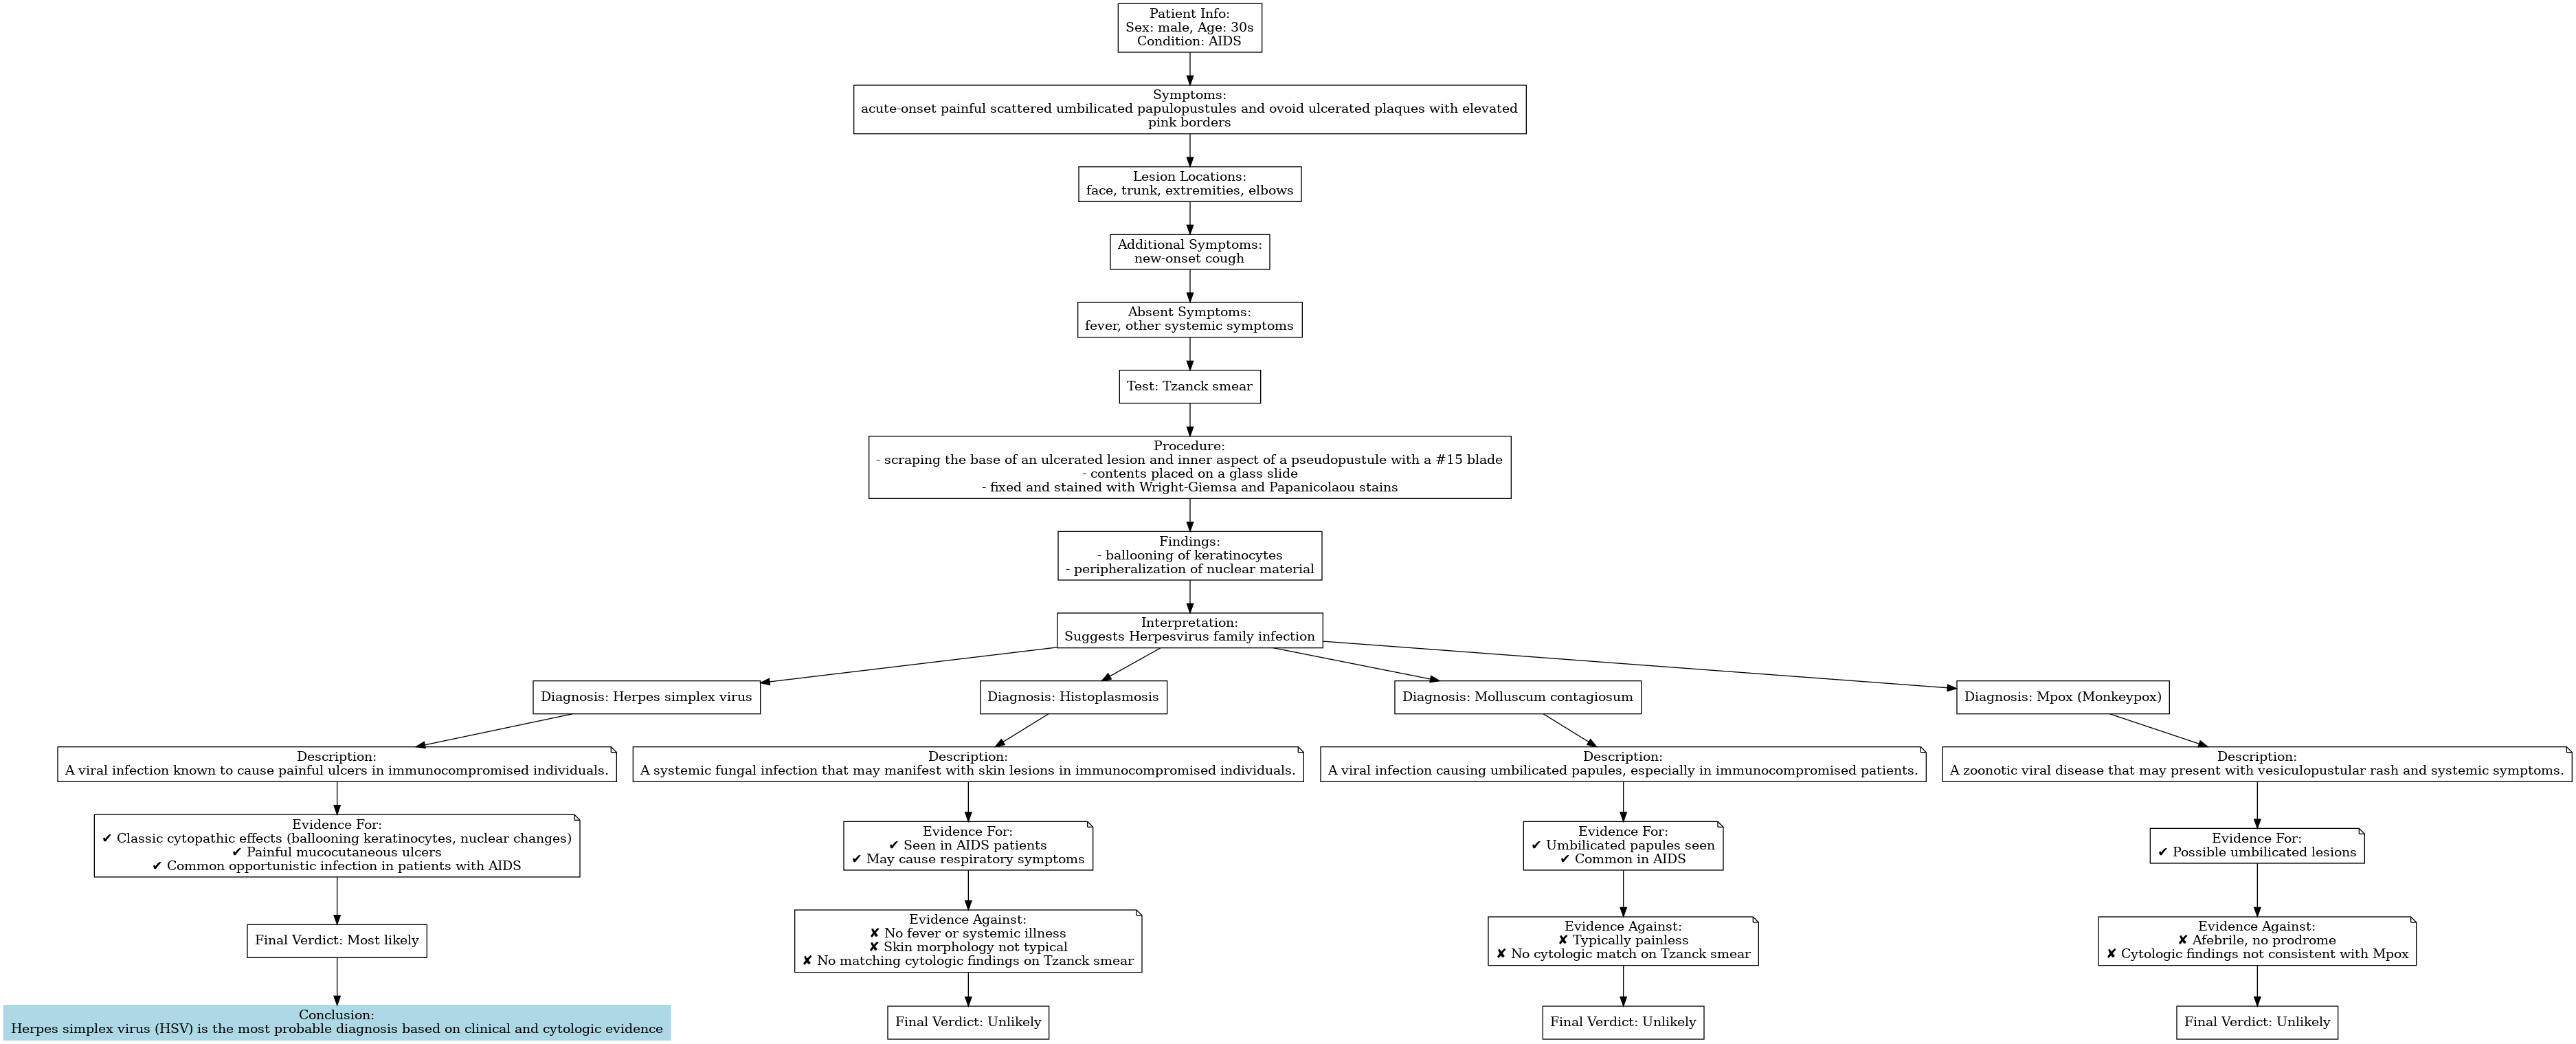

In [8]:
import json
from graphviz import Digraph
from IPython.display import Image

# Load detailed JSON
with open('Sample1.json', 'r') as f:
    data = json.load(f)

dot = Digraph(comment='Modular Clinical Reasoning Tree')
dot.attr(rankdir='TB', fontsize='10')

# Patient case: general info
case = data['patient_case']
dot.node('A1', f"Patient Info:\nSex: {case['sex']}, Age: {case['age']}\nCondition: {case['condition']}", shape='box')

# Symptoms
dot.node('A2', "Symptoms:\n" + '\n'.join(case['presentation'].split(', ')), shape='box')
dot.edge('A1', 'A2')

# Lesion distribution
dot.node('A3', "Lesion Locations:\n" + ', '.join(case['lesion_distribution']), shape='box')
dot.edge('A2', 'A3')

# Additional and absent symptoms
dot.node('A4', f"Additional Symptoms:\n{', '.join(case['additional_symptoms'])}", shape='box')
dot.edge('A3', 'A4')

dot.node('A5', f"Absent Symptoms:\n{', '.join(case['absent_symptoms'])}", shape='box')
dot.edge('A4', 'A5')

# Diagnostic test: method
test = data['diagnostic_test']
dot.node('B1', f"Test: {test['name']}", shape='box')
dot.edge('A5', 'B1')

dot.node('B2', "Procedure:\n- " + '\n- '.join(test['procedure']), shape='box')
dot.edge('B1', 'B2')

dot.node('B3', "Findings:\n- " + '\n- '.join(test['findings']), shape='box')
dot.edge('B2', 'B3')

# Interpretation
branch = data['reasoning_tree']['branch'][0]
dot.node('C1', f"Interpretation:\n{branch['interpretation']}", shape='box')
dot.edge('B3', 'C1')

# Diagnostic options
for i, option in enumerate(branch['diagnostic_options']):
    base_id = f"D{i}"
    
    dot.node(f"{base_id}a", f"Diagnosis: {option['option']}", shape='box')
    dot.edge('C1', f"{base_id}a")
    
    dot.node(f"{base_id}b", f"Description:\n{option['description']}", shape='note')
    dot.edge(f"{base_id}a", f"{base_id}b")
    
    if option['evidence_for']:
        dot.node(f"{base_id}c", "Evidence For:\n✔ " + '\n✔ '.join(option['evidence_for']), shape='note')
        dot.edge(f"{base_id}b", f"{base_id}c")
    
    if option['evidence_against']:
        dot.node(f"{base_id}d", "Evidence Against:\n✘ " + '\n✘ '.join(option['evidence_against']), shape='note')
        last = f"{base_id}c" if option['evidence_for'] else f"{base_id}b"
        dot.edge(last, f"{base_id}d")
        final_edge_source = f"{base_id}d"
    else:
        final_edge_source = f"{base_id}c" if option['evidence_for'] else f"{base_id}b"
    
    # Final verdict
    dot.node(f"{base_id}e", f"Final Verdict: {option['final_verdict']}", shape='box')
    dot.edge(final_edge_source, f"{base_id}e")
    
    # Connect "Most likely" to final conclusion
    if option['final_verdict'].lower() == 'most likely':
        dot.edge(f"{base_id}e", 'Z')

# Final diagnosis
dot.node('Z', f"Conclusion:\n{data['reasoning_tree']['conclusion']}", shape='box', style='filled', color='lightblue')

# Render and display
dot.render('modular_reasoning_tree', format='png', cleanup=True)
Image(filename='modular_reasoning_tree.png')
